In [1]:
import os
import copy
import numpy as np
import pandas as pd
import geopandas as gpd

from pathlib import Path

from src import utils, stats_utils
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=1.25)

from src.data.lfs import EulfsDs

%load_ext autoreload
%autoreload 2

In [2]:
config_paths = "paths_config.yml"
config_data = "data_config.yml"

In [49]:
eulfs = EulfsDs(fn_config_path=config_paths, fn_config_data=config_data)

In [21]:
fpath_fr = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\FR_YEAR_1998_onwards\FR2019_y.csv"
fpath_de = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\DE_YEAR_1998_onwards\DE2019_y.csv"
fpath_pl = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\PL_YEAR_1998_onwards\PL2019_y.csv"
fpath_bg = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\BG_YEAR_1998_onwards\BG2019_y.csv"


In [73]:
cntry = "MT"
fpath = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles" \
        r"\{}_YEAR_1998_onwards\{}2019_y.csv".format(cntry, cntry)

df = pd.read_csv(fpath, usecols=eulfs.variables, na_values=eulfs.na_values,
                 dtype=eulfs.dtypes_in)
df[df.COUNTRYW == '000-OWN COUNTRY']
df

,SEX,WSTATOR,NACE1D,ISCO3D,COUNTRYW,REGIONW,FTPT,REFYEAR,COUNTRY,REGION,DEGURBA,HHTYPE,COEFF,AGE,ILOSTAT,EDUC4WN,HATLEV1D,MAINSTAT,INCDECIL
0,1,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,1,1,0.01375,77,3,0,M,4,NaN
1,2,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,1,1,0.01100,77,3,0,M,4,NaN
2,2,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,1,1,0.01600,47,3,0,L,7,NaN
3,1,1,H,800,000-OWN COUNTRY,NaN,1,2019,MT,NaN,1,1,0.01225,52,1,0,L,1,08
4,1,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,1,1,0.01725,22,2,1,L,8,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20971,1,1,K,100,000-OWN COUNTRY,NaN,1,2019,MT,NaN,2,1,0.02250,57,1,0,M,1,10
20972,2,1,K,300,000-OWN COUNTRY,NaN,1,2019,MT,NaN,2,1,0.01875,52,1,0,M,1,08
20973,1,1,C,200,000-OWN COUNTRY,NaN,1,2019,MT,NaN,2,1,0.03250,27,1,0,H,1,08
20974,2,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,2,1,0.04875,37,2,1,L,2,NaN


In [46]:
df.REGIONW.str[:1]

0        NaN
1        NaN
2          K
3          K
4          K
        ... 
82931      M
82932    NaN
82933      M
82934      M
82935      M
Name: REGIONW, Length: 82936, dtype: object

In [28]:
gdf = gpd.read_file(r"T:\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\data\external\geodata\NUTS_RG_03M_2021_3035.shp")

(1300000.0, 5500000.0)

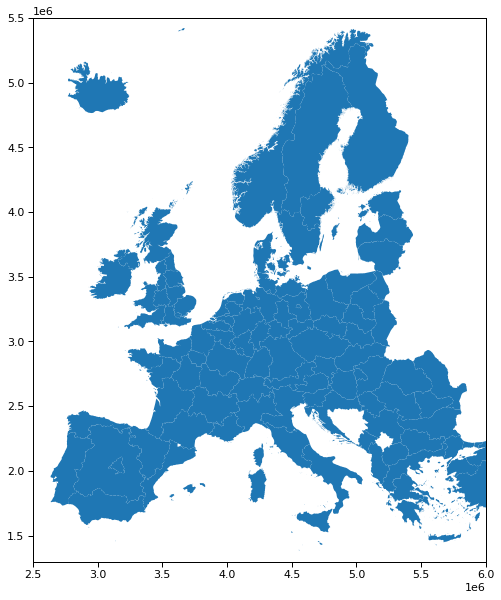

In [129]:
ax = gdf[gdf["LEVL_CODE"] == 1].plot(figsize=(10,10))

xmin, xmax, ymin, ymax = [2500000.0, 6000000.0, 1300000.0, 5500000.0]
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

In [58]:
gdf[(gdf["LEVL_CODE"] == 1) & (gdf["CNTR_CODE"] == "UK")]

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry
85,UKN,1,UK,Northern Ireland,Northern Ireland,0.0,NaN,0,UKN,"MULTIPOLYGON (((3309324.536 3662898.099, 33092..."
104,UKF,1,UK,East Midlands (England),East Midlands (England),0.0,NaN,0,UKF,"POLYGON ((3661305.282 3425260.635, 3662445.963..."
114,UKD,1,UK,North West (England),North West (England),0.0,NaN,0,UKD,"MULTIPOLYGON (((3533199.349 3588017.661, 35317..."
115,UKE,1,UK,Yorkshire and the Humber,Yorkshire and the Humber,0.0,NaN,0,UKE,"POLYGON ((3625708.122 3546887.147, 3628368.658..."
123,UKI,1,UK,London,London,0.0,NaN,0,UKI,"POLYGON ((3640447.811 3214203.213, 3643592.962..."
124,UKJ,1,UK,South East (England),South East (England),0.0,NaN,0,UKJ,"MULTIPOLYGON (((3598326.240 3274989.145, 35923..."
268,UKG,1,UK,West Midlands (England),West Midlands (England),0.0,NaN,0,UKG,"POLYGON ((3540819.430 3350364.018, 3541111.170..."
328,UKH,1,UK,East of England,East of England,0.0,NaN,0,UKH,"MULTIPOLYGON (((3760200.001 3324800.736, 37615..."
379,UKC,1,UK,North East (England),North East (England),0.0,NaN,0,UKC,"MULTIPOLYGON (((3592155.267 3610215.783, 35938..."
401,UKM,1,UK,Scotland,Scotland,0.0,NaN,0,UKM,"MULTIPOLYGON (((3730295.196 4236213.811, 37304..."


In [159]:
df_all = eulfs.read(year=2019, covariates=True)

In [160]:
df_all

,SEX,WSTATOR,NACE1D,ISCO3D,COUNTRYW,REGIONW,FTPT,REFYEAR,COUNTRY,REGION,...,COEFF_share_green_esco_median,COEFF_share_green_esco_iqr,COEFF_share_brown_esco_mean,COEFF_share_brown_esco_std,COEFF_share_brown_esco_median,COEFF_share_brown_esco_iqr,COEFF_share_neutral_esco_mean,COEFF_share_neutral_esco_std,COEFF_share_neutral_esco_median,COEFF_share_neutral_esco_iqr
0,1,1,C,132,AT,12,1,2019,AT,10,...,1.280184,3.270349,1.310335,2.879087,0.0000,1.561437,78.380695,6.216517,79.705862,5.083656
1,1,1,G,311,AT,12,1,2019,AT,10,...,2.751750,6.879375,1.198619,2.855575,0.0000,1.421305,74.043807,12.870001,78.207632,9.660811
2,2,1,G,411,AT,12,1,2019,AT,10,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,47.232500,0.000000,47.232500,0.000000
3,2,1,Q,911,AT,12,1,2019,AT,10,...,2.521190,1.334058,0.518645,0.902814,0.0000,0.756357,49.757904,1.892336,49.919571,1.359269
4,1,1,O,011,AT,12,1,2019,AT,10,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,75.636719,0.782129,75.862500,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1546564,1,2,G,421,UK,M0,2,2019,UK,M0,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,1098.125092,7.539097,1100.140000,0.000000
1546565,1,1,O,211,UK,M0,1,2019,UK,M0,...,81.391364,241.461045,81.733828,130.918147,29.8435,99.478333,1533.571009,328.865733,1690.013933,244.983955
1546566,1,1,H,833,UK,M0,1,2019,UK,M0,...,59.957419,68.310462,40.006625,69.027988,0.0000,64.235318,1700.616274,208.502745,1722.679024,147.931174
1546567,2,1,Q,263,UK,M0,1,2019,UK,M0,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,1719.291582,16.704197,1723.300000,0.000000


In [161]:
def perc_missing(df):
    return df.isna().sum() / df.shape[0]

perc_missing(df_all)

SEX                                0.000000
WSTATOR                            0.000000
NACE1D                             0.003823
ISCO3D                             0.000000
COUNTRYW                           0.000000
                                     ...   
COEFF_share_brown_esco_iqr         0.010458
COEFF_share_neutral_esco_mean      0.010458
COEFF_share_neutral_esco_std       0.034960
COEFF_share_neutral_esco_median    0.010458
COEFF_share_neutral_esco_iqr       0.010458
Length: 64, dtype: float64

In [123]:
countries = ["NL"]
perc_missing(df_all.loc[df_all["COUNTRY"].isin(countries)])

SEX                                0.000000
WSTATOR                            0.000000
NACE1D                             0.090380
ISCO3D                             0.000000
COUNTRYW                           0.000000
REGIONW                            1.000000
FTPT                               0.000000
REFYEAR                            0.000000
COUNTRY                            0.000000
REGION                             1.000000
DEGURBA                            0.000000
HHTYPE                             0.000000
COEFF                              0.000000
AGE                                0.000000
ILOSTAT                            0.000000
EDUC4WN                            0.000000
HATLEV1D                           0.008874
MAINSTAT                           0.000485
INCDECIL                           0.167079
NUTS_ID                            0.000000
ISCO                               0.000000
share_green_gtp_mean               0.604765
share_green_gtp_std             

In [ ]:
ix_isco = df_all.loc[:, "ISCO3D"].sort_values().index.values
df_all.iloc[ix_isco]

In [ ]:
cols = ["COEFF_share_green_esco_mean", "COEFF_share_brown_esco_mean",
        "COEFF_share_neutral_esco_mean"]

np.allclose(df_all.loc[:, cols].sum(axis=1), df_all.COEFF)
error = np.abs(df_all.loc[:, cols].sum(axis=1) - df_all.COEFF)

df_all.iloc[error.sort_values(ascending=False).index.values]

Group by LFS variables

In [12]:
age_by_gbn_shares = df_all.groupby("AGE")["COEFF_share_green_esco_mean",
                           "COEFF_share_brown_esco_mean",
                      "COEFF_share_neutral_esco_mean"].sum()

coeff_by_age = df_all.groupby("AGE")["COEFF"].sum()

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_8500\3363292881.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  age_by_gbn_shares = df_all.groupby("AGE")["COEFF_share_green_esco_mean",


In [13]:
age_by_gbn_shares_rel = age_by_gbn_shares.copy()
for col in age_by_gbn_shares_rel.columns:
    age_by_gbn_shares_rel[col] = age_by_gbn_shares_rel[col] / coeff_by_age

In [18]:
age_by_gbn_shares_rel.sum(axis=1)

AGE
17    0.962025
22    0.905101
27    0.896504
32    0.891347
37    0.889521
42    0.892786
47    0.908163
52    0.924474
57    0.921102
62    0.917660
67    0.908257
72    0.908590
77    0.911586
dtype: float64

<AxesSubplot:xlabel='AGE'>

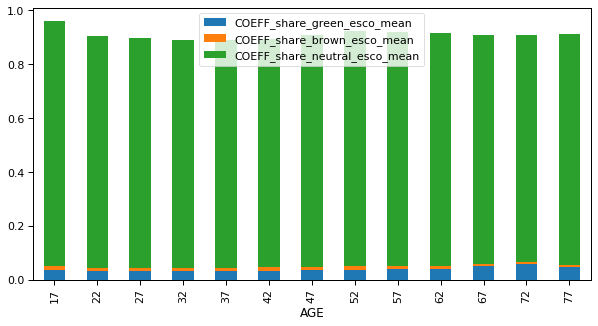

In [14]:
age_by_gbn_shares_rel.plot.bar(stacked=True, figsize=(10, 5))